# Model: Support Vector Machine (LinearSVC) for PERM Visa Denial
**Member:** IT25102357  
**Model:** Linear Support Vector Machine (`sklearn.svm.LinearSVC`)  
**Dataset:** handover **B** `results/outputs/final_processed.csv.gz` (25 selected, scaled features)  
**Group:** 2026-Y02-S1-MLB-B9G1-08  
**Task:** binary classification: `denied` = 1 (Denied) vs 0 (Certified / Certified-Expired)

**Covers:** Step 3 (model design, implementation, hyperparameter tuning, pipeline steps) and Step 4 (metrics, k-fold CV, comparison of varieties) for my individual Final Evaluation.

---
## 1. Why a linear SVM suits this dataset

**How it works.** An SVM looks for the boundary that separates denied from approved applications with the **widest possible margin**. Points close to the boundary (the *support vectors*) decide where it goes. `C` controls how strictly the margin must be respected: small `C` gives a wide, tolerant margin (simpler model); large `C` gives a narrow margin that tries to classify every training row correctly.

**Why LinearSVC (not a kernel SVC):**
1. **Size.** A kernel (RBF) SVC scales roughly O(n²) in time and memory, which is infeasible on 283,879 training rows × 5 CV folds. LinearSVC trains in a few seconds.
2. **Prepared data.** Stage 5 standardised the numeric features and Stage 6 removed redundant ones, which is what a margin-based model needs (features on comparable scales, little multicollinearity).
3. **Imbalance.** `class_weight='balanced'` makes each denied row count ~13.5× more, so the margin isn't drawn just to fit the 93% approved rows.
4. **Interpretable.** Each feature has one weight: positive pushes towards "denied", negative towards "approved".

**Important difference from Logistic Regression:** LinearSVC gives no probabilities (`predict_proba`), only a **decision score** (`decision_function`, the signed distance to the margin). PR-AUC, ROC-AUC and the decision threshold are therefore all computed on this score.

## 2. Evaluation design (shared by all six group models)

| Decision | Choice | Why |
|---|---|---|
| Train / test | The `split` column from Stage 1 (stratified 80/20, seed 42) | Every member uses the same rows, so the six models are comparable |
| Validation | **5-fold `StratifiedKFold`** (shuffle, seed 42) on the train rows only | The assignment requires k-fold CV; every fold keeps 6.9% denied |
| Main metric | **PR-AUC** (`average_precision`) | Measures how well denials are ranked above approvals; robust to the rare class |
| Test set | Used **once**, at the end | Using it to make choices would make the score optimistic |

**Accuracy trap:** 93.1% of applications are approved, so "always approve" already scores 93.1% accuracy while catching no denials (variety S0).

### Block 1: Setup

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict
from sklearn.metrics import (make_scorer, average_precision_score, roc_auc_score, precision_score, recall_score,
                             f1_score, accuracy_score, balanced_accuracy_score, confusion_matrix,
                             precision_recall_curve, roc_curve, ConfusionMatrixDisplay, classification_report)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, 'results', 'outputs')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
OUT_DIR = os.path.join(ROOT, 'results', 'outputs')
SVM_DIR = os.path.join(ROOT, 'results', 'models', 'IT25102357_SVM')
os.makedirs(SVM_DIR, exist_ok=True)

TARGET, SEED = 'denied', 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
# LinearSVC has no predict_proba: the PR-AUC / ROC-AUC scorers automatically use decision_function
SCORING = {'pr_auc': 'average_precision', 'roc_auc': 'roc_auc', 'f1': 'f1',
           'precision': make_scorer(precision_score, zero_division=0), 'recall': 'recall', 'accuracy': 'accuracy'}
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
warnings.filterwarnings('ignore', category=FutureWarning)
print('Results folder:', SVM_DIR)

Results folder: /Users/jathushansundararasu/Desktop/us_prem_visa/results/models/IT25102357_SVM


### Block 2: Load handover B with the shared split
No new `train_test_split`: the split was fixed in Stage 1, so every member trains and tests on identical rows.

In [2]:
def load_handover(version='B'):
    name = {'A': 'cleaned_unscaled_allfeatures.csv.gz', 'B': 'final_processed.csv.gz'}[version]
    df = pd.read_csv(os.path.join(OUT_DIR, name))
    train, test = df[df['split'].eq('train')], df[df['split'].eq('test')]
    return (train.drop(columns=[TARGET, 'split']), train[TARGET],
            test.drop(columns=[TARGET, 'split']), test[TARGET])

X_train, y_train, X_test, y_test = load_handover('B')
print(f'X_train {X_train.shape}, X_test {X_test.shape} | denied rate train {y_train.mean():.2%}, test {y_test.mean():.2%}')
print(f'"Always approve" accuracy on test: {1 - y_test.mean():.2%}')

X_train (283879, 25), X_test (70970, 25) | denied rate train 6.91%, test 6.91%
"Always approve" accuracy on test: 93.09%


### Block 3: A helper that scores any variety with 5-fold CV
`cross_validate` trains the model 5 times, each time scoring on the held-out fold of the **train** rows, and returns mean ± standard deviation. F1, precision and recall use the default decision threshold (score > 0); PR-AUC and ROC-AUC are threshold-free.

In [3]:
rows, models = [], {}

def evaluate_cv(name, description, estimator):
    scores = cross_validate(estimator, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
    row = {'variety': name, 'description': description}
    for m in SCORING:
        row[f'{m}_mean'], row[f'{m}_std'] = scores[f'test_{m}'].mean(), scores[f'test_{m}'].std()
    rows.append(row)
    models[name] = estimator
    print(f"{name}: PR-AUC {row['pr_auc_mean']:.4f} ± {row['pr_auc_std']:.4f} | F1 {row['f1_mean']:.3f} | "
          f"recall {row['recall_mean']:.3f} | precision {row['precision_mean']:.3f} | accuracy {row['accuracy_mean']:.3f}")


def linear_svc(**params):
    return LinearSVC(dual=False, max_iter=5000, random_state=SEED, **params)

## 3. Model varieties ("different pre-processing and hyperparameter tune-ups")

| Variety | What changes | Question it answers |
|---|---|---|
| **S0** | `DummyClassifier`: always predicts "approved" | What does a useless model score? (accuracy trap) |
| **S1** | LinearSVC, `C=1`, no class weights | What happens if the imbalance is ignored? |
| **S2** | LinearSVC, `C=1`, `class_weight='balanced'` | Does re-weighting the rare class help? |
| **S3** | `GridSearchCV` over `C` × penalty (L1 / L2), balanced | What are the best hyperparameters? |
| **S4** | SMOTE oversampling inside an `imblearn` Pipeline + best S3 settings | Is synthetic oversampling better than class weights? |

### Block 4: S0 baseline, S1 no weights, S2 class weights

In [4]:
evaluate_cv('S0', 'Dummy: always approve', DummyClassifier(strategy='most_frequent'))
evaluate_cv('S1', 'LinearSVC, C=1, no class weights', linear_svc(C=1.0))
evaluate_cv('S2', 'LinearSVC, C=1, class_weight=balanced', linear_svc(C=1.0, class_weight='balanced'))

S0: PR-AUC 0.0691 ± 0.0000 | F1 0.000 | recall 0.000 | precision 0.000 | accuracy 0.931


S1: PR-AUC 0.3234 ± 0.0087 | F1 0.179 | recall 0.099 | precision 0.892 | accuracy 0.937


S2: PR-AUC 0.3250 ± 0.0072 | F1 0.251 | recall 0.656 | precision 0.155 | accuracy 0.730


### Block 5: S3 hyperparameter tuning with GridSearchCV
- **`C`**: margin softness. Small = wide, tolerant margin (strong regularisation); large = narrow margin.
- **`penalty`**: **L2** shrinks all weights smoothly; **L1** can set useless weights to exactly 0 (built-in feature selection).

5 values of `C` × 2 penalties = 10 combinations × 5 folds = **50 fits**, scored by PR-AUC; the best combination is refit on all train rows.

In [5]:
grid = GridSearchCV(linear_svc(class_weight='balanced'),
                    {'C': [0.001, 0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2']},
                    scoring='average_precision', cv=CV, n_jobs=-1, return_train_score=True)
grid.fit(X_train, y_train)
best = grid.best_params_
print(f'Best parameters: {best} | best CV PR-AUC {grid.best_score_:.4f}')

grid_table = pd.DataFrame(grid.cv_results_)[['param_C', 'param_penalty', 'mean_test_score', 'std_test_score',
                                              'mean_train_score', 'rank_test_score']]
grid_table = grid_table.rename(columns={'mean_test_score': 'cv_pr_auc', 'std_test_score': 'cv_std',
                                        'mean_train_score': 'train_pr_auc'}).sort_values('rank_test_score')
grid_table.to_csv(os.path.join(SVM_DIR, 'grid_search_results.csv'), index=False)
display(grid_table.pivot(index='param_C', columns='param_penalty', values='cv_pr_auc').round(4))

evaluate_cv('S3', f"GridSearch best: C={best['C']}, penalty={best['penalty']}, balanced",
            linear_svc(class_weight='balanced', **best))

Best parameters: {'C': 10, 'penalty': 'l2'} | best CV PR-AUC 0.3251


param_penalty,l1,l2
param_C,,
0.001,0.3114,0.3179
0.010,0.3237,0.3240
0.100,0.3249,0.3249
1.000,0.3250,0.3250
10.000,0.3251,0.3251


S3: PR-AUC 0.3251 ± 0.0072 | F1 0.251 | recall 0.656 | precision 0.155 | accuracy 0.730


### Block 6: S4 SMOTE inside a pipeline (different pre-processing)
SMOTE creates synthetic denied applications by interpolating between real denied neighbours. Inside the `imblearn` Pipeline it is applied **only to the training folds**; validation folds and the test set stay 100% real. No class weights here: SMOTE does the balancing instead.

In [6]:
evaluate_cv('S4', 'SMOTE (in-fold) + LinearSVC, best C / penalty',
            ImbPipeline([('smote', SMOTE(random_state=SEED)), ('svm', linear_svc(**best))]))

S4: PR-AUC 0.3227 ± 0.0069 | F1 0.247 | recall 0.661 | precision 0.152 | accuracy 0.721


## 4. Comparison of the varieties

### Block 7: Table, chart and choice of the final variety
**Rule (fixed before looking at the test set):** highest mean CV PR-AUC among S1–S4. Varieties within one standard deviation of the top count as tied; then prefer the tuned model S3, then S2, S1, S4 (SMOTE adds synthetic data).

,variety,description,pr_auc_mean,pr_auc_std,roc_auc_mean,f1_mean,recall_mean,precision_mean,accuracy_mean
0,S0,Dummy: always approve,0.0691,0.0000,0.5000,0.0000,0.0000,0.0000,0.9309
1,S1,"LinearSVC, C=1, no class weights",0.3234,0.0087,0.7641,0.1787,0.0993,0.8917,0.9369
2,S2,"LinearSVC, C=1, class_weight=balanced",0.3250,0.0072,0.7699,0.2510,0.6557,0.1552,0.7296
3,S3,"GridSearch best: C=10, penalty=l2, balanced",0.3251,0.0072,0.7699,0.2510,0.6557,0.1552,0.7296
4,S4,"SMOTE (in-fold) + LinearSVC, best C / penalty",0.3227,0.0069,0.7684,0.2469,0.6609,0.1518,0.7214


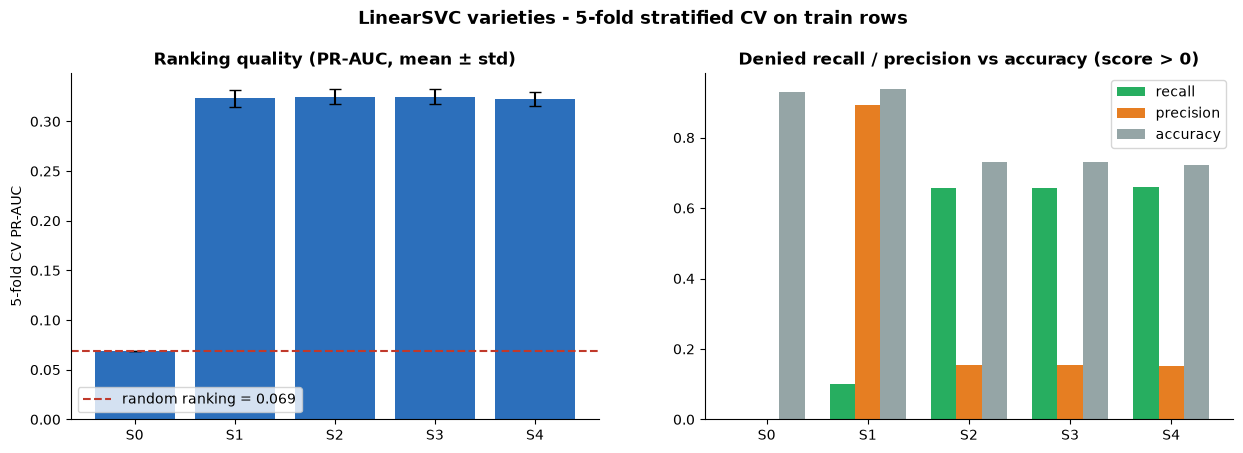

Highest CV PR-AUC: S3 (0.3251 ± 0.0072) | tied within 1 std: ['S3', 'S2', 'S1', 'S4']
Selected variety: S3 - GridSearch best: C=10, penalty=l2, balanced


In [7]:
table = pd.DataFrame(rows)
table.to_csv(os.path.join(SVM_DIR, 'cv_varieties.csv'), index=False)
display(table[['variety', 'description', 'pr_auc_mean', 'pr_auc_std', 'roc_auc_mean', 'f1_mean',
               'recall_mean', 'precision_mean', 'accuracy_mean']].round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
x = np.arange(len(table))
axes[0].bar(x, table['pr_auc_mean'], yerr=table['pr_auc_std'], capsize=4, color='#2c6fbb')
axes[0].axhline(y_train.mean(), color='#c0392b', ls='--', label=f'random ranking = {y_train.mean():.3f}')
axes[0].set_xticks(x, table['variety']); axes[0].set_ylabel('5-fold CV PR-AUC')
axes[0].set_title('Ranking quality (PR-AUC, mean ± std)', fontweight='bold'); axes[0].legend()
w = 0.25
for i, (m, c) in enumerate([('recall_mean', '#27ae60'), ('precision_mean', '#e67e22'), ('accuracy_mean', '#95a5a6')]):
    axes[1].bar(x + (i - 1) * w, table[m], w, label=m.replace('_mean', ''), color=c)
axes[1].set_xticks(x, table['variety']); axes[1].legend()
axes[1].set_title('Denied recall / precision vs accuracy (score > 0)', fontweight='bold')
plt.suptitle('LinearSVC varieties - 5-fold stratified CV on train rows', fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(SVM_DIR, 'cv_varieties_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

cand = table[table['variety'].isin(['S1', 'S2', 'S3', 'S4'])].sort_values('pr_auc_mean', ascending=False)
top = cand.iloc[0]
tied = cand[cand['pr_auc_mean'] >= top['pr_auc_mean'] - top['pr_auc_std']]['variety']
best_name = sorted(tied, key=['S3', 'S2', 'S1', 'S4'].index)[0]
print(f'Highest CV PR-AUC: {top.variety} ({top.pr_auc_mean:.4f} ± {top.pr_auc_std:.4f}) | tied within 1 std: {list(tied)}')
print(f'Selected variety: {best_name} - {table.set_index("variety").loc[best_name, "description"]}')

## 5. Decision threshold

### Block 8: Threshold from out-of-fold decision scores
The default rule "denied if score > 0" is arbitrary for imbalanced data. We choose the score cut-off that **maximises F1 for Denied**, using **out-of-fold** scores: every train row is scored by a model that never saw it. The test set is not used.

Best threshold on decision_function = 0.405 -> OOF F1 0.331 (precision 0.322, recall 0.339)
Default 0 -> OOF F1 0.251


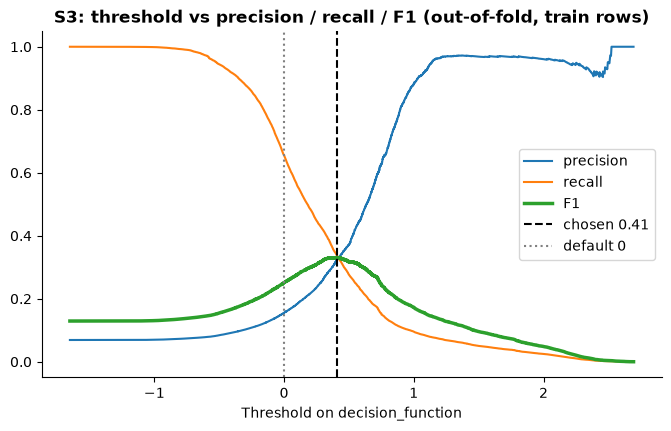

In [8]:
oof = cross_val_predict(models[best_name], X_train, y_train, cv=CV, method='decision_function', n_jobs=-1)
p, r, th = precision_recall_curve(y_train, oof)
f1s = 2 * p[:-1] * r[:-1] / np.clip(p[:-1] + r[:-1], 1e-12, None)
THRESHOLD = float(th[np.argmax(f1s)])
print(f'Best threshold on decision_function = {THRESHOLD:.3f} -> OOF F1 {f1s.max():.3f} '
      f'(precision {p[np.argmax(f1s)]:.3f}, recall {r[np.argmax(f1s)]:.3f})')
print(f'Default 0 -> OOF F1 {f1_score(y_train, (oof > 0).astype(int)):.3f}')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(th, p[:-1], label='precision'); ax.plot(th, r[:-1], label='recall'); ax.plot(th, f1s, lw=2.5, label='F1')
ax.axvline(THRESHOLD, color='black', ls='--', label=f'chosen {THRESHOLD:.2f}')
ax.axvline(0, color='grey', ls=':', label='default 0')
ax.set_xlabel('Threshold on decision_function'); ax.legend()
ax.set_title(f'{best_name}: threshold vs precision / recall / F1 (out-of-fold, train rows)', fontweight='bold')
plt.savefig(os.path.join(SVM_DIR, 'threshold_tuning.png'), dpi=200, bbox_inches='tight')
plt.show()

## 6. Final evaluation on the test set (used once)

### Block 9: Fit on all train rows, evaluate on the 70,970 untouched test rows, save `test_metrics.json`

In [9]:
final_model = models[best_name].fit(X_train, y_train)
svm_step = final_model.named_steps['svm'] if hasattr(final_model, 'named_steps') else final_model
test_score = final_model.decision_function(X_test)
test_pred = (test_score >= THRESHOLD).astype(int)
row = table.set_index('variety').loc[best_name]
params = svm_step.get_params()

test_metrics = {
    'member': 'IT25102357', 'model': 'Support Vector Machine (LinearSVC)', 'variety': best_name, 'dataset': 'B',
    'params': {k: params[k] for k in ('C', 'penalty', 'class_weight')},
    'threshold': round(THRESHOLD, 4), 'threshold_on': 'decision_function',
    'cv_pr_auc_mean': round(float(row['pr_auc_mean']), 4), 'cv_pr_auc_std': round(float(row['pr_auc_std']), 4),
    'test_pr_auc': round(average_precision_score(y_test, test_score), 4),
    'test_roc_auc': round(roc_auc_score(y_test, test_score), 4),
    'test_f1_denied': round(f1_score(y_test, test_pred), 4),
    'test_precision_denied': round(precision_score(y_test, test_pred), 4),
    'test_recall_denied': round(recall_score(y_test, test_pred), 4),
    'test_balanced_accuracy': round(balanced_accuracy_score(y_test, test_pred), 4),
    'test_accuracy': round(accuracy_score(y_test, test_pred), 4),
    'baseline_accuracy_always_approve': round(1 - float(y_test.mean()), 4),
}
with open(os.path.join(SVM_DIR, 'test_metrics.json'), 'w') as f:
    json.dump(test_metrics, f, indent=2)
print(json.dumps(test_metrics, indent=2))
print(classification_report(y_test, test_pred, target_names=['Approved (0)', 'Denied (1)'], digits=3))

{
  "member": "IT25102357",
  "model": "Support Vector Machine (LinearSVC)",
  "variety": "S3",
  "dataset": "B",
  "params": {
    "C": 10,
    "penalty": "l2",
    "class_weight": "balanced"
  },
  "threshold": 0.4054,
  "threshold_on": "decision_function",
  "cv_pr_auc_mean": 0.3251,
  "cv_pr_auc_std": 0.0072,
  "test_pr_auc": 0.3184,
  "test_roc_auc": 0.7658,
  "test_f1_denied": 0.3277,
  "test_precision_denied": 0.3186,
  "test_recall_denied": 0.3374,
  "test_balanced_accuracy": 0.6419,
  "test_accuracy": 0.9043,
  "baseline_accuracy_always_approve": 0.9309
}
              precision    recall  f1-score   support

Approved (0)      0.951     0.946     0.948     66065
  Denied (1)      0.319     0.337     0.328      4905

    accuracy                          0.904     70970
   macro avg      0.635     0.642     0.638     70970
weighted avg      0.907     0.904     0.906     70970



### Block 10: Confusion matrix, PR / ROC curves and feature weights
Weights are on standardised (or 0/1) features, so their sizes are comparable: **positive** pushes towards "denied", **negative** towards "approved".

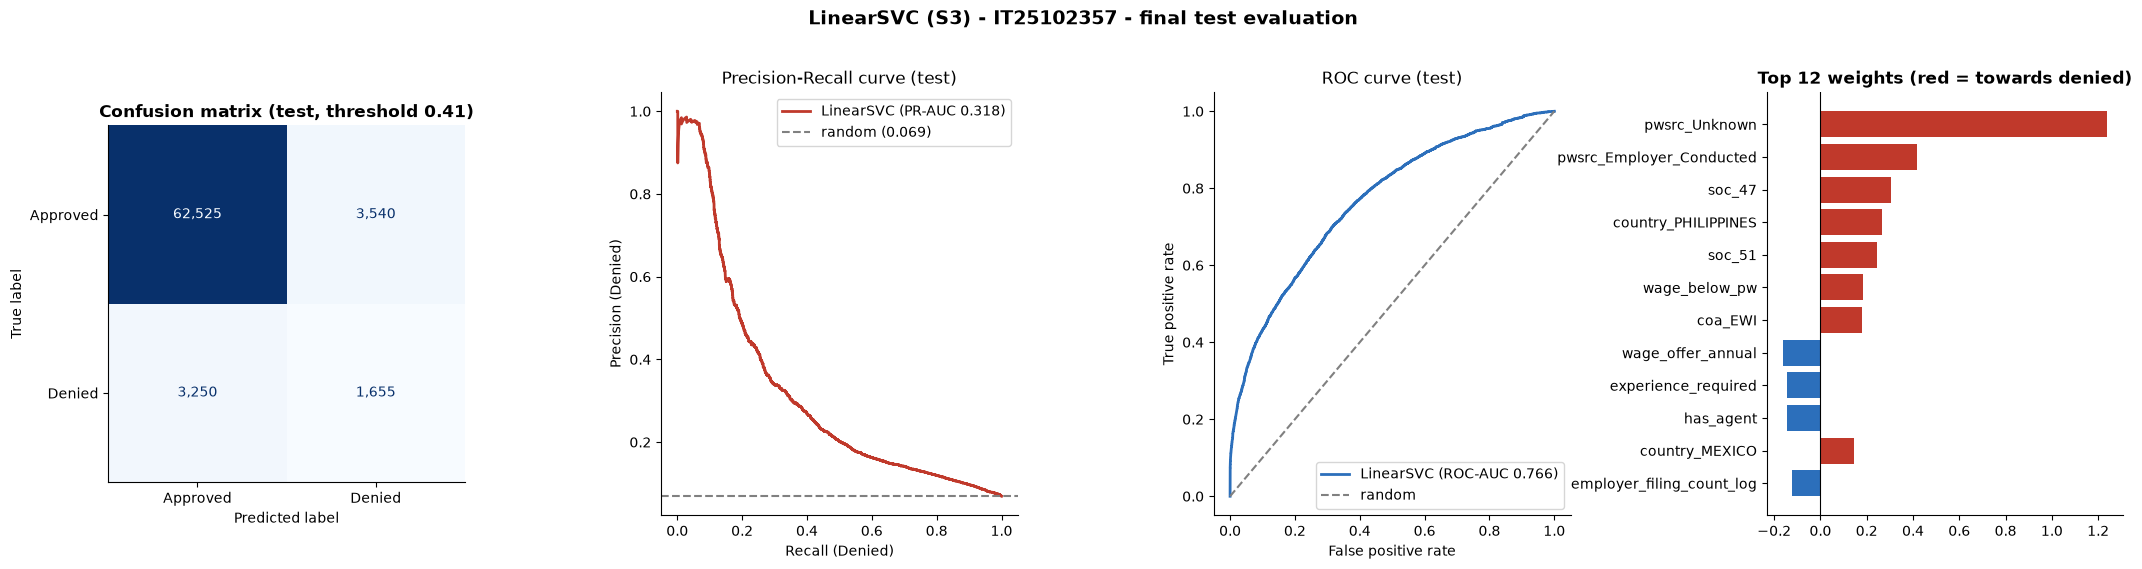

Saved: ['coefficients.csv', 'cv_varieties.csv', 'cv_varieties_comparison.png', 'grid_search_results.csv', 'test_evaluation.png', 'test_metrics.json', 'threshold_tuning.png']


In [10]:
coef = pd.Series(svm_step.coef_[0], index=X_train.columns)
coef.rename('weight').to_csv(os.path.join(SVM_DIR, 'coefficients.csv'))

fig, ax = plt.subplots(1, 4, figsize=(26, 5.5))
plt.subplots_adjust(wspace=0.55)
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred), display_labels=['Approved', 'Denied']).plot(
    ax=ax[0], cmap='Blues', values_format=',', colorbar=False)
ax[0].set_title(f'Confusion matrix (test, threshold {THRESHOLD:.2f})', fontweight='bold')
pc, rc, _ = precision_recall_curve(y_test, test_score)
ax[1].plot(rc, pc, color='#c0392b', lw=2, label=f"LinearSVC (PR-AUC {test_metrics['test_pr_auc']:.3f})")
ax[1].axhline(y_test.mean(), color='grey', ls='--', label=f'random ({y_test.mean():.3f})')
ax[1].set(xlabel='Recall (Denied)', ylabel='Precision (Denied)', title='Precision-Recall curve (test)'); ax[1].legend()
fpr, tpr, _ = roc_curve(y_test, test_score)
ax[2].plot(fpr, tpr, color='#2c6fbb', lw=2, label=f"LinearSVC (ROC-AUC {test_metrics['test_roc_auc']:.3f})")
ax[2].plot([0, 1], [0, 1], color='grey', ls='--', label='random')
ax[2].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC curve (test)'); ax[2].legend()
top_w = coef.reindex(coef.abs().sort_values(ascending=False).head(12).index).iloc[::-1]
ax[3].barh(top_w.index, top_w.values, color=np.where(top_w.values > 0, '#c0392b', '#2c6fbb'))
ax[3].axvline(0, color='black', lw=0.8)
ax[3].set_title('Top 12 weights (red = towards denied)', fontweight='bold')
plt.suptitle(f'LinearSVC ({best_name}) - IT25102357 - final test evaluation', fontsize=14, fontweight='bold', y=1.03)
plt.savefig(os.path.join(SVM_DIR, 'test_evaluation.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', sorted(os.listdir(SVM_DIR)))

## 7. Conclusion (write this in your own words after running)

1. **Accuracy trap (S0 vs S1):** S0 scores ___% accuracy with 0 recall; S1 catches only ___% of denials.
2. **Class weights (S1 → S2):** recall ___ → ___; PR-AUC ___ → ___. Do weights change the ranking or only the threshold?
3. **Tuning (S3):** best `C` = ___, penalty = ___. How flat is the grid? Train vs CV PR-AUC: any overfitting?
4. **SMOTE (S4) vs class weights:** better or not, and worth the extra cost?
5. **Final test result (threshold ___):** PR-AUC ___, F1 ___, precision ___, recall ___; CV vs test.
6. **Strongest weights:** which features push towards denial / approval, and do they make domain sense?
7. **Comparison with Logistic Regression (the other linear model) and limitations** (linear boundary, low precision, `pwsrc_Unknown` shortcut, no probabilities).